1. Importing Libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

2. Load Dataset

In [14]:
# Load the dataset
df = pd.read_csv("AdventureWorks Product Lookup.csv")

# Preview dataset
df.head()

,ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
0,214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap...",Red,0,0,13.0863,34.9900
1,215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap...",Black,0,0,12.0278,33.6442
2,218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,M,U,3.3963,9.5000
3,219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers st...,White,L,U,3.3963,9.5000
4,220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap...",Blue,0,0,12.0278,33.6442


3. Before Data cleaning : Dataset Overview

In [15]:
# Check dataset structure
df.info()

# Check number of rows and columns
print(df.shape)

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ProductKey             293 non-null    int64  
 1   ProductSubcategoryKey  293 non-null    int64  
 2   ProductSKU             293 non-null    object 
 3   ProductName            293 non-null    object 
 4   ModelName              293 non-null    object 
 5   ProductDescription     293 non-null    object 
 6   ProductColor           243 non-null    object 
 7   ProductSize            293 non-null    object 
 8   ProductStyle           293 non-null    object 
 9   ProductCost            293 non-null    float64
 10  ProductPrice           293 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 25.3+ KB
(293, 11)


,ProductKey,ProductSubcategoryKey,ProductCost,ProductPrice
count,293.000000,293.000000,293.000000,293.000000
mean,441.552901,12.283276,413.661009,714.437357
std,108.064327,9.892831,517.611849,872.157258
min,214.000000,1.000000,0.856500,2.290000
25%,354.000000,2.000000,31.724400,63.500000
50%,457.000000,12.000000,199.375700,333.420000
75%,533.000000,17.000000,601.743700,1003.910000
max,606.000000,37.000000,2171.294200,3578.270000


4. Check Duplicate Rows

In [16]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

5. Check Missing Values

In [17]:
# Check missing values
df.isnull().sum()

ProductKey                0
ProductSubcategoryKey     0
ProductSKU                0
ProductName               0
ModelName                 0
ProductDescription        0
ProductColor             50
ProductSize               0
ProductStyle              0
ProductCost               0
ProductPrice              0
dtype: int64

6. Handle Missing Values 

In [8]:
df['ProductColor'] = df['ProductColor'].fillna(df['ProductColor'].mode()[0])
print(df.isnull().sum())

ProductKey               0
ProductSubcategoryKey    0
ProductSKU               0
ProductName              0
ModelName                0
ProductDescription       0
ProductColor             0
ProductSize              0
ProductStyle             0
ProductCost              0
ProductPrice             0
dtype: int64


7. Fix Data Types

In [18]:
# Fix datatypes

df['ProductSKU'] = df['ProductSKU'].astype('string')
df['ProductName'] = df['ProductName'].astype('string')
df['ModelName'] = df['ModelName'].astype('string')
df['ProductDescription'] = df['ProductDescription'].astype('string')

df['ProductColor'] = df['ProductColor'].astype('string')
df['ProductSize'] = df['ProductSize'].astype('string')
df['ProductStyle'] = df['ProductStyle'].astype('string')

df['ProductCost'] = df['ProductCost'].astype('float')
df['ProductPrice'] = df['ProductPrice'].astype('float')

# Check datatypes
df.dtypes

ProductKey                        int64
ProductSubcategoryKey             int64
ProductSKU               string[python]
ProductName              string[python]
ModelName                string[python]
ProductDescription       string[python]
ProductColor             string[python]
ProductSize              string[python]
ProductStyle             string[python]
ProductCost                     float64
ProductPrice                    float64
dtype: object

8. Clean Text Columns

In [19]:
text_cols = ['ProductSKU', 'ProductName', 'ModelName', 'ProductDescription']

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df['ProductName'] = df['ProductName'].str.title()
df['ModelName'] = df['ModelName'].str.title()

df['ProductColor'] = df['ProductColor'].str.upper()
df['ProductSize'] = df['ProductSize'].str.upper()
df['ProductStyle'] = df['ProductStyle'].str.upper()
df['ProductSKU'] = df['ProductSKU'].str.upper()
df.head(5)

,ProductKey,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
0,214,31,HL-U509-R,"Sport-100 Helmet, Red",Sport-100,"Universal fit, well-vented, lightweight , snap...",RED,0,0,13.0863,34.9900
1,215,31,HL-U509,"Sport-100 Helmet, Black",Sport-100,"Universal fit, well-vented, lightweight , snap...",BLACK,0,0,12.0278,33.6442
2,218,23,SO-B909-M,"Mountain Bike Socks, M",Mountain Bike Socks,Combination of natural and synthetic fibers st...,WHITE,M,U,3.3963,9.5000
3,219,23,SO-B909-L,"Mountain Bike Socks, L",Mountain Bike Socks,Combination of natural and synthetic fibers st...,WHITE,L,U,3.3963,9.5000
4,220,31,HL-U509-B,"Sport-100 Helmet, Blue",Sport-100,"Universal fit, well-vented, lightweight , snap...",BLUE,0,0,12.0278,33.6442


9. Check unique categories

In [20]:
# Check unique values in categorical columns
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:5] for col in df.columns]  # first 5 unique values as sample
})

# Display summary
print(unique_summary)

                   Column  Unique_Count  \
0              ProductKey           293   
1   ProductSubcategoryKey            37   
2              ProductSKU           293   
3             ProductName           293   
4               ModelName           119   
5      ProductDescription           115   
6            ProductColor             9   
7             ProductSize            19   
8            ProductStyle             4   
9             ProductCost           111   
10           ProductPrice           107   

                                        Sample_Values  
0                           [214, 215, 218, 219, 220]  
1                                [31, 23, 19, 21, 14]  
2   [HL-U509-R, HL-U509, SO-B909-M, SO-B909-L, HL-...  
3   [Sport-100 Helmet, Red, Sport-100 Helmet, Blac...  
4   [Sport-100, Mountain Bike Socks, Cycling Cap, ...  
5   [Universal fit, well-vented, lightweight , sna...  
6                    [RED, BLACK, WHITE, BLUE, MULTI]  
7                                  

10. Feature engineering

In [23]:
# FEATURE ENGINEERING - PRODUCT DATASET

# 1️.Profit & Profit Margin
df['Profit'] = df['ProductPrice'] - df['ProductCost']
df['ProfitMargin'] = round((df['Profit'] / df['ProductPrice']) * 100, 2)

# 2️.Price Category (Low / Medium / High)
def price_category(price):
    if price < 20:
        return 'Low'
    elif price < 50:
        return 'Medium'
    else:
        return 'High'

df['PriceCategory'] = df['ProductPrice'].apply(price_category)

# 3️.Product Type (from ProductName)
df['Type'] = df['ProductName'].str.split(' ').str[0]

# 4.Size Category
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large', '0': 'Unknown', 'Unknown':'Unknown'}
df['Size'] = df['ProductSize'].map(size_map).fillna('Unknown')

# 5.Style Category
df['Style'] = df['ProductStyle'].replace({'U':'Universal','Unknown':'Unknown'}).fillna('Unknown')

# FINAL CHECK
print("Columns after feature engineering:\n", df.columns)
print("\nSample data after features:\n", df.head())

Columns after feature engineering:
 Index(['ProductKey', 'ProductSubcategoryKey', 'ProductSKU', 'ProductName',
       'ModelName', 'ProductDescription', 'ProductColor', 'ProductSize',
       'ProductStyle', 'ProductCost', 'ProductPrice', 'Profit', 'ProfitMargin',
       'PriceCategory', 'Type', 'Size', 'Style'],
      dtype='object')

Sample data after features:
    ProductKey  ProductSubcategoryKey ProductSKU              ProductName  \
0         214                     31  HL-U509-R    Sport-100 Helmet, Red   
1         215                     31    HL-U509  Sport-100 Helmet, Black   
2         218                     23  SO-B909-M   Mountain Bike Socks, M   
3         219                     23  SO-B909-L   Mountain Bike Socks, L   
4         220                     31  HL-U509-B   Sport-100 Helmet, Blue   

             ModelName                                 ProductDescription  \
0            Sport-100  Universal fit, well-vented, lightweight , snap...   
1            Sport-100 

10. Remove unnecessary columns

In [24]:
# columns not useful for analysis
remove_cols = ['ProductSKU', 'ModelName', 'ProductDescription']
df = df.drop(columns= remove_cols)

In [25]:
# columns not useful for analysis
remove_cols = ['ProductSize','ProductStyle','ProductName']
df = df.drop(columns= remove_cols)
df.columns

Index(['ProductKey', 'ProductSubcategoryKey', 'ProductColor', 'ProductCost',
       'ProductPrice', 'Profit', 'ProfitMargin', 'PriceCategory', 'Type',
       'Size', 'Style'],
      dtype='object')

11. Columns Renaming

In [26]:
df.rename(columns={
    'ProductSubcategoryKey': 'SubcategoryID'
}, inplace=True)
df.columns

Index(['ProductKey', 'SubcategoryID', 'ProductColor', 'ProductCost',
       'ProductPrice', 'Profit', 'ProfitMargin', 'PriceCategory', 'Type',
       'Size', 'Style'],
      dtype='object')

12. Arrange columns

In [29]:
# Arrange columns in proper order
df = df[[
    'ProductKey', 'SubcategoryID', 
    'Type', 'Size', 'Style',
    'ProductCost', 'ProductPrice', 'Profit', 'ProfitMargin', 'PriceCategory'
]]

# Check dataset
df.head(5)

,ProductKey,SubcategoryID,Type,Size,Style,ProductCost,ProductPrice,Profit,ProfitMargin,PriceCategory
0,214,31,Sport-100,Unknown,0,13.0863,34.9900,21.9037,62.60,Medium
1,215,31,Sport-100,Unknown,0,12.0278,33.6442,21.6164,64.25,Medium
2,218,23,Mountain,Medium,Universal,3.3963,9.5000,6.1037,64.25,Low
3,219,23,Mountain,Large,Universal,3.3963,9.5000,6.1037,64.25,Low
4,220,31,Sport-100,Unknown,0,12.0278,33.6442,21.6164,64.25,Medium


13. Outlier detection

In [ ]:
# Detect outliers using IQR for each column
# Numeric columns
numeric_cols = ['ProductCost', 'ProductPrice', 'Profit', 'ProfitMargin']

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} outliers:\n", outliers[col].values, "\n")
    
    # Remove outliers
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Reset index
df.reset_index(drop=True, inplace=True)

# Check dataset shape
print("Dataset shape after outlier removal:", df.shape)

ProductCost outliers:
 [2171.2942 2171.2942 2171.2942 2171.2942 2171.2942 1912.1544 1912.1544
 1912.1544 1912.1544 1898.0944 1898.0944 1898.0944 1898.0944 1518.7864
 1518.7864 1518.7864 1481.9379 1481.9379 1481.9379 1481.9379 1481.9379
 1481.9379 1481.9379 1481.9379] 

ProductPrice outliers:
 [2071.4196 2071.4196 2071.4196 2049.0982 2049.0982 2049.0982 2181.5625
 2181.5625 2181.5625 2181.5625 2181.5625] 

Profit outliers:
 [] 

ProfitMargin outliers:
 [] 

Dataset shape after outlier removal: (258, 10)


C:\Users\naina\AppData\Local\Temp\ipykernel_27484\3181072344.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols, patch_artist=True)


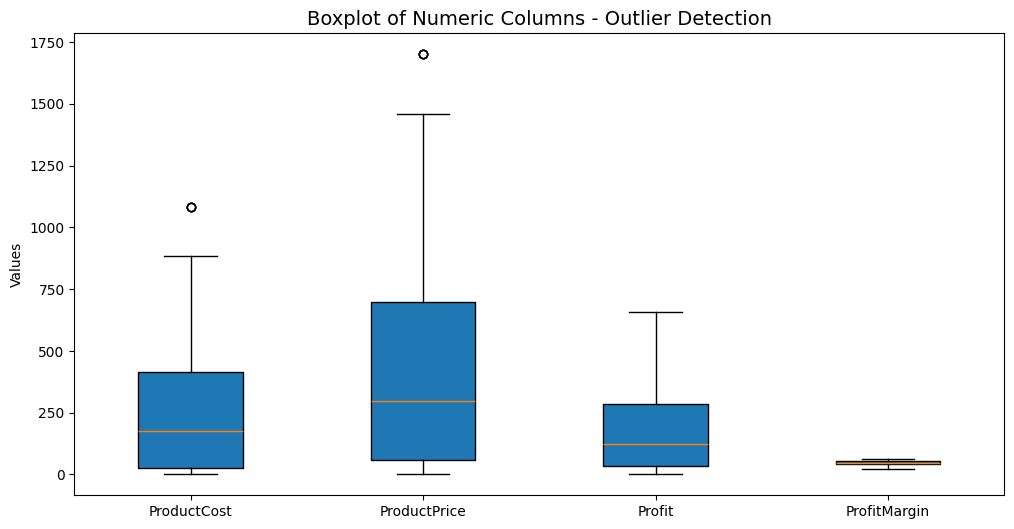

In [35]:
# Detect outliers using Boxplot
import matplotlib.pyplot as plt

# Numeric columns
numeric_cols = ['ProductCost', 'ProductPrice', 'Profit', 'ProfitMargin']

# Set up the figure
plt.figure(figsize=(12,6))
plt.title("Boxplot of Numeric Columns - Outlier Detection", fontsize=14)

# Create boxplot for all numeric columns
plt.boxplot([df[col] for col in numeric_cols], labels=numeric_cols, patch_artist=True)

# Add y-label
plt.ylabel("Values")

# Show plot
plt.show()

14. After Data cleaning

In [36]:
# 1️.Check Missing Values
print(df.isnull().sum())

# 2.Check Duplicate Rows
print(df.duplicated().sum())

# 3.Reset Index After Row Removal
df = df.reset_index(drop=True)

# 4.Verify Final Dataset Shape
print(df.shape)

# 5.Data preview
print(df.head(5))

ProductKey       0
SubcategoryID    0
Type             0
Size             0
Style            0
ProductCost      0
ProductPrice     0
Profit           0
ProfitMargin     0
PriceCategory    0
dtype: int64
0
(258, 10)
   ProductKey  SubcategoryID       Type     Size      Style  ProductCost  \
0         214             31  Sport-100  Unknown          0      13.0863   
1         215             31  Sport-100  Unknown          0      12.0278   
2         218             23   Mountain   Medium  Universal       3.3963   
3         219             23   Mountain    Large  Universal       3.3963   
4         220             31  Sport-100  Unknown          0      12.0278   

   ProductPrice   Profit  ProfitMargin PriceCategory  
0       34.9900  21.9037         62.60        Medium  
1       33.6442  21.6164         64.25        Medium  
2        9.5000   6.1037         64.25           Low  
3        9.5000   6.1037         64.25           Low  
4       33.6442  21.6164         64.25        Medium 

15. Save Cleaned Dataset

In [38]:
df.to_csv("Cleaned_Product_Data.csv", index=False)